In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
import os
import pandas as pd


NOTEBOOK_PATH = os.getcwd()


if NOTEBOOK_PATH.endswith("Users") or NOTEBOOK_PATH.endswith("koutr"):
    PROJECT_DIR = r"C:\Users\koutr\OneDrive\Υπολογιστής\Bank Churn Project"
    os.chdir(PROJECT_DIR)
    NOTEBOOK_PATH = os.getcwd()

print("Current working directory:", NOTEBOOK_PATH)


DATA_PATH = os.path.join(NOTEBOOK_PATH, "data", "raw", "Bank Customer Churn Prediction.csv")

print("Loading from:", DATA_PATH)


df = pd.read_csv(DATA_PATH)
df.head()

Current working directory: C:\Users\koutr\OneDrive\Υπολογιστής\Bank Churn Project
Loading from: C:\Users\koutr\OneDrive\Υπολογιστής\Bank Churn Project\data\raw\Bank Customer Churn Prediction.csv


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.shape

(10000, 12)

In [4]:
df.dtypes

customer_id           int64
credit_score          int64
country              object
gender               object
age                   int64
tenure                int64
balance             float64
products_number       int64
credit_card           int64
active_member         int64
estimated_salary    float64
churn                 int64
dtype: object

In [7]:
# Fix data types to ensure correct behavior in modeling and statistical analysis

# Convert true binary/numeric variables to int
for col in ['churn', 'active_member', 'credit_card']:
    df[col] = df[col].astype(int)

# Convert nominal variables to categorical for memory efficiency and cleaner encoding
for col in ['country', 'gender']:
    df[col] = df[col].astype('category')

df['products_number'] = df['products_number'].astype(int)

# Quick check
df.dtypes

customer_id            int64
credit_score           int64
country             category
gender              category
age                    int64
tenure                 int64
balance              float64
products_number        int32
credit_card            int32
active_member          int32
estimated_salary     float64
churn                  int32
dtype: object

In [6]:
# Missing values
missing = df.isnull().sum().sort_values(ascending = False)
missing = missing[missing > 0]

if len(missing) > 0:
    print("\u2705 Missing values found: \n")
    print(missing)
else:
    print("\u2705 No missing values found in the dataset")

✅ No missing values found in the dataset


In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [8]:
df[df.duplicated()]

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn


In [9]:
# Καθαρίζει κεφαλαία/κενά
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [9]:
# Generate a quick overview of each column in the dataframe.
# The summary includes:
# - data type
# - number of unique values
# - missing values (count and percentage)
# - min, max, mean, median for numerical columns
def quick_summary(df):
    """
    Creates a compact summary table for each column in the dataframe.
    """
    summary = pd.DataFrame({
        'dtype': df.dtypes,
        'nunique': df.nunique(),
        'missing': df.isna().sum(),
        'missing_%': (df.isna().sum() / len(df) * 100).round(2),
    })
    
    # Only for numeric columns
    numeric_df = df.select_dtypes(include='number')
    summary.loc[numeric_df.columns, 'min'] = numeric_df.min()
    summary.loc[numeric_df.columns, 'max'] = numeric_df.max()
    summary.loc[numeric_df.columns, 'mean'] = numeric_df.mean().round(2)
    summary.loc[numeric_df.columns, 'median'] = numeric_df.median().round(2)
    
    return summary

# Run summary
quick_summary(df)


,dtype,nunique,missing,missing_%,min,max,mean,median
customer_id,int64,10000,0,0.0,15565701.00,15815690.00,15690940.57,15690738.00
credit_score,int64,460,0,0.0,350.00,850.00,650.53,652.00
country,object,3,0,0.0,NaN,NaN,NaN,NaN
gender,object,2,0,0.0,NaN,NaN,NaN,NaN
age,int64,70,0,0.0,18.00,92.00,38.92,37.00
tenure,int64,11,0,0.0,0.00,10.00,5.01,5.00
balance,float64,6382,0,0.0,0.00,250898.09,76485.89,97198.54
products_number,int64,4,0,0.0,1.00,4.00,1.53,1.00
credit_card,int64,2,0,0.0,0.00,1.00,0.71,1.00
active_member,int64,2,0,0.0,0.00,1.00,0.52,1.00


# Outliers Detection

In [12]:
import numpy as np
import pandas as pd

def detect_outliers_iqr(df, cols=None, threshold=1.5):
    """
    Εντοπίζει outliers σε numeric στήλες βάσει IQR.
    Επιστρέφει DataFrame με boolean flags για κάθε στήλη.
    """
    if cols is None:
        cols = df.select_dtypes(include='number').columns
    
    outlier_flags = pd.DataFrame(index=df.index)
    
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - threshold * IQR
        upper = Q3 + threshold * IQR
        outlier_flags[col] = (df[col] < lower) | (df[col] > upper)
    
    outlier_counts = outlier_flags.sum().sort_values(ascending=False)
    print("📊 Outliers per column:\n", outlier_counts[outlier_counts > 0])
    
    return outlier_flags

In [13]:
outlier_flags = detect_outliers_iqr(df, cols=['credit_score', 'balance', 'estimated_salary', 'age'])

📊 Outliers per column:
 age             359
credit_score     15
dtype: int64


In [14]:
# Προβολή ελάχιστων και μέγιστων ηλικιών
print("Min age:", df['age'].min())
print("Max age:", df['age'].max())

# Προβολή των πολύ νέων (<18) και πολύ μεγάλων (>80)
young_customers = df[df['age'] < 18]
old_customers = df[df['age'] > 80]

# Συνολικός αριθμός εγγραφών
total_customers = len(df)

# Εμφάνιση πλήθους και ποσοστού
if not young_customers.empty:
    pct_young = (len(young_customers) / total_customers) * 100
    print(f"🧒 Πελάτες κάτω των 18 ετών: {len(young_customers)} ({pct_young:.2f}%)")
    display(young_customers.head())
else:
    print("✅ Δεν υπάρχουν πελάτες κάτω των 18 ετών.")

if not old_customers.empty:
    pct_old = (len(old_customers) / total_customers) * 100
    print(f"👴 Πελάτες άνω των 80 ετών: {len(old_customers)} ({pct_old:.2f}%)")
    display(old_customers.head())
else:
    print("✅ Δεν υπάρχουν πελάτες άνω των 80 ετών.")

Min age: 18
Max age: 92
✅ Δεν υπάρχουν πελάτες κάτω των 18 ετών.
👴 Πελάτες άνω των 80 ετών: 12 (0.12%)


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
766,15810864,700,France,Female,82,2,0.00,2,0,1,182055.36,0
2458,15813303,513,Spain,Male,88,10,0.00,2,1,1,52952.24,0
3033,15578006,787,France,Female,85,10,0.00,2,1,1,116537.96,0
3387,15798024,537,Germany,Male,84,8,92242.34,1,1,1,186235.98,0
3531,15653251,408,France,Female,84,8,87873.39,1,0,0,188484.52,1


In [15]:
import numpy as np

# Δημιουργούμε νέα στήλη age_capped για χρήση σε plots & μοντελοποίηση
df['age_capped'] = np.where(df['age'] > 80, 80, df['age'])

print(f"✅ age_capped column created. Max capped value: {df['age_capped'].max()}")

✅ age_capped column created. Max capped value: 80


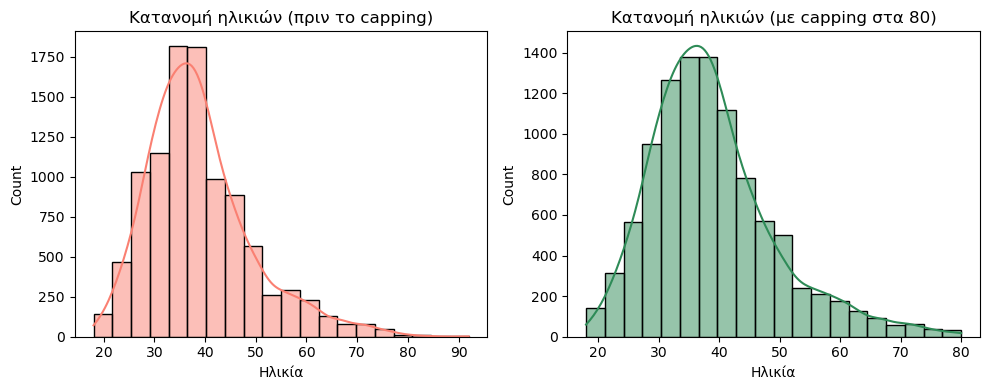

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

# Πριν το capping
plt.subplot(1,2,1)
sns.histplot(df['age'], bins=20, kde=True, color='salmon')
plt.title("Κατανομή ηλικιών (πριν το capping)")
plt.xlabel("Ηλικία")

# Μετά το capping
plt.subplot(1,2,2)
sns.histplot(df['age_capped'], bins=20, kde=True, color='seagreen')
plt.title("Κατανομή ηλικιών (με capping στα 80)")
plt.xlabel("Ηλικία")

plt.tight_layout()
plt.show()

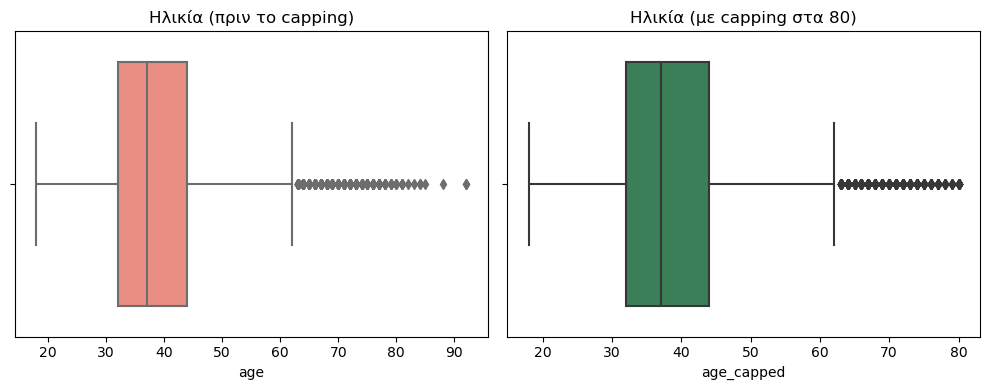

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

# Πριν το capping
plt.subplot(1,2,1)
sns.boxplot(x=df['age'], color='salmon')
plt.title("Ηλικία (πριν το capping)")
plt.xlabel("age")

# Μετά το capping
plt.subplot(1,2,2)
sns.boxplot(x=df['age_capped'], color='seagreen')
plt.title("Ηλικία (με capping στα 80)")
plt.xlabel("age_capped")

plt.tight_layout()
plt.show()

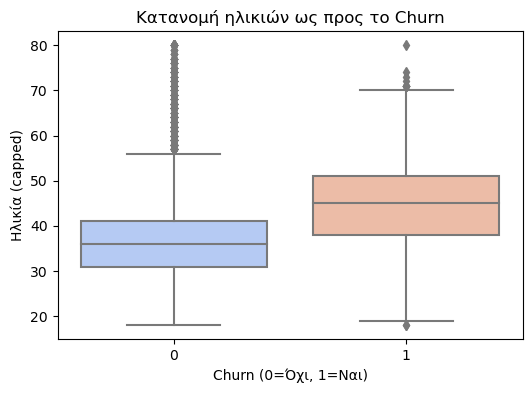

In [18]:
plt.figure(figsize=(6,4))
sns.boxplot(x='churn', y='age_capped', data=df, palette='coolwarm')
plt.title("Κατανομή ηλικιών ως προς το Churn")
plt.xlabel("Churn (0=Όχι, 1=Ναι)")
plt.ylabel("Ηλικία (capped)")
plt.show()

- Οι churners είναι κατά μέσο όρο μεγαλύτερης ηλικίας.

# Sanity checks

In [19]:
import numpy as np

print("🔍 Sanity Checks Report\n" + "-"*40)

# 1️⃣ Age range
invalid_age = df[(df['age'] < 18) | (df['age'] > 100)]
print(f"👤 Invalid age entries: {invalid_age.shape[0]}")

# 2️⃣ Credit score range (300–900 typical)
invalid_score = df[(df['credit_score'] < 300) | (df['credit_score'] > 900)]
print(f"💳 Invalid credit_score entries: {invalid_score.shape[0]}")

# 3️⃣ Balance must be non-negative
invalid_balance = df[df['balance'] < 0]
print(f"💰 Negative balance entries: {invalid_balance.shape[0]}")

# 4️⃣ Products_number must be >= 1
invalid_products = df[df['products_number'] < 1]
print(f"📦 Invalid products_number (<1): {invalid_products.shape[0]}")

# 5️⃣ Binary columns should be {0,1}
binary_cols = ['churn', 'credit_card', 'active_member']
for col in binary_cols:
    invalid_bin = df[~df[col].isin([0, 1])]
    print(f"⚙️ Invalid {col} entries: {invalid_bin.shape[0]}")

# 6️⃣ Unique customer IDs
duplicates = df[df['customer_id'].duplicated()]
print(f"🧾 Duplicate customer_id: {duplicates.shape[0]}")

print("-"*40)
print("✅ Sanity checks completed.")

🔍 Sanity Checks Report
----------------------------------------
👤 Invalid age entries: 0
💳 Invalid credit_score entries: 0
💰 Negative balance entries: 0
📦 Invalid products_number (<1): 0
⚙️ Invalid churn entries: 0
⚙️ Invalid credit_card entries: 0
⚙️ Invalid active_member entries: 0
🧾 Duplicate customer_id: 0
----------------------------------------
✅ Sanity checks completed.


C:\Users\koutr\New folder\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


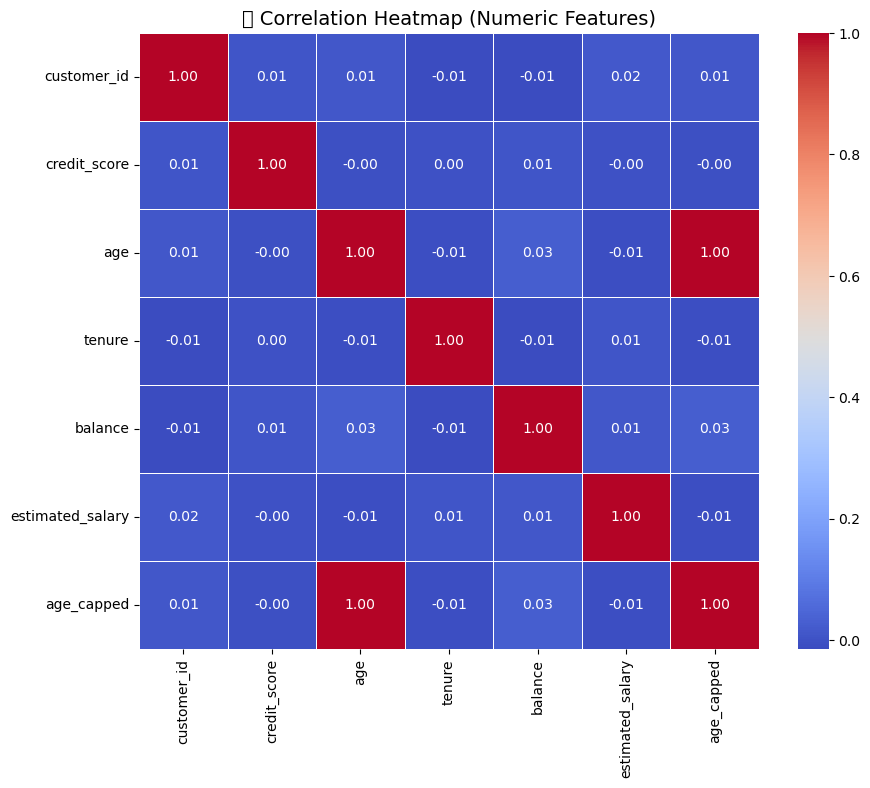

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Επιλέγουμε ΜΟΝΟ numeric στήλες
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Υπολογισμός πίνακα συσχετίσεων
corr_matrix = numeric_df.corr()

# Οπτικοποίηση
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("📊 Correlation Heatmap (Numeric Features)", fontsize=14)
plt.show()

### ✅ Summary — Data Preparation Completed

- Rows: 10,000  
- Columns: 12  
- No missing or duplicate values  
- Outliers capped (age > 80)  
- Sanity checks passed (no invalid ranges)  
- Correlation heatmap validated  
- Dataset exported: `data/processed/bank_churn_cleaned_final.csv`

➡️ Ready to proceed to **02_eda.ipynb**